In [1]:
from datasets import load_dataset
dataset = load_dataset("imdb")
texts = dataset["train"]["text"][:5000]  # sample subset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_texts = [clean_text(t) for t in texts]


In [4]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError

tokens = [word_tokenize(t) for t in cleaned_texts]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_tokens = [[w for w in tok if w not in stop_words] for tok in tokens]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

lemmatized_tokens = [lemmatize(t) for t in filtered_tokens]


In [7]:
from collections import Counter

vocab = Counter([w for doc in lemmatized_tokens for w in doc])
print(vocab.most_common(20))


[('br', 11956), ('movie', 11018), ('film', 8383), ('not', 8035), ('one', 5123), ('make', 4824), ('do', 4734), ('like', 4687), ('see', 4385), ('bad', 3955), ('get', 3809), ('good', 3457), ('would', 3084), ('well', 3030), ('even', 2998), ('watch', 2918), ('s', 2882), ('go', 2868), ('character', 2841), ('time', 2694)]


In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform([" ".join(t) for t in lemmatized_tokens])

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform([" ".join(t) for t in lemmatized_tokens])


In [10]:
!pip install gensim
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=lemmatized_tokens, vector_size=100, window=5, min_count=2, workers=4)
word_vector = w2v_model.wv['movie']  # example word embedding

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.4 MB/s eta 0:00:00


In [12]:
import numpy as np

def sentence_embedding(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

sentence_embeddings = [sentence_embedding(t) for t in lemmatized_tokens]


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(sentence_embeddings)
# Find most similar comments for the first review
similar_idx = similarities[0].argsort()[-5:][::-1]
for i in similar_idx:
    print(texts[i])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

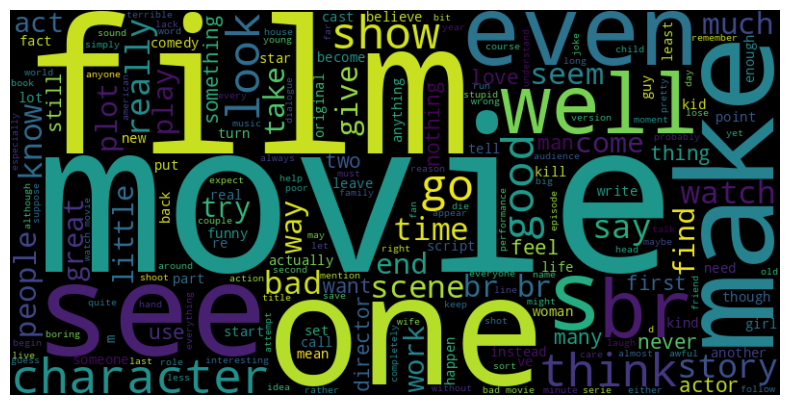

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(" ".join([w for doc in lemmatized_tokens for w in doc]))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
